# Week 8 — Small data: embeddings, linear probes, fine-tuning & self-supervision

**Course:** Data Science for Electron Microscopy — FAU Erlangen-Nürnberg  
**Author:** Prof. Dr. Philipp Pelz  
**Topic:** Small data: augmentation, transfer & self-supervision  
**Time estimate:** ~90–120 minutes  
**Colab:** [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ECLIPSE-Lab/public_presentations/blob/main/data_science_for_em/notebooks/week08_embeddings_transfer.ipynb)

---

## The scenario

You have a new microscope ("the real instrument") and a new question: *is this micrograph coarse-, medium- or fine-grained?*
Labelling is expensive, but you can acquire **unlabelled** images all day, and you have a **simulator** (Voronoi grains) that produces unlimited labelled synthetic images — from a *different* domain (no vignetting, different blur and dose).

## What you will do

1. **Generate data** for three roles: labelled synthetic images (simulator), an **unlabelled pool** from the real instrument, and a small labelled real set + a held-out real test set.
2. **Pretrain two backbones** without any real labels:
   (a) *supervised on synthetic labels* (sim → real transfer), (b) *self-supervised SimCLR* on the unlabelled real pool.
3. **Inspect the embeddings:** PCA maps and **kNN retrieval** — do neighbours in embedding space share the grain-size class?
4. **Compare protocols vs number of labels:** from scratch · linear probe (random / sim-supervised / SimCLR backbone) · fine-tune (LP → FT).
5. **Exercise:** implement *precision@k* for embedding retrieval.

**Runs on CPU, no downloads, whole notebook in a few minutes.** The optional ImageNet cell at the end is switched off by default.

---

## Instructions

- Read each section, run the code cell, then try the `(try this yourself)` markers.
- Exercise cells ship with a **working version** and `# TODO` markers — try to write it yourself first, then compare.
- `assert` statements check the key claims — they must all pass.
- A non-executable **Solution** cell follows each exercise.

In [1]:
# --- Imports & reproducibility -------------------------------------------------
# Colab: everything used here is pre-installed (numpy, scipy, matplotlib, scikit-learn, torch)
import copy, time
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.decomposition import PCA

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
# Tiny 32x32 CNNs gain nothing from many threads; one thread is fastest and most reproducible.
torch.set_num_threads(1)

%matplotlib inline
plt.rcParams['figure.dpi'] = 110
T_START = time.time()
print("Imports OK — torch", torch.__version__)

Imports OK — torch 2.7.1+cu126


---

## Part 1 — Data: a simulator, an unlabelled pool, and a few real labels

Each image is a 32×32 Voronoi grain map (random grain intensity = channelling contrast, dark boundaries).

| Role | Domain | Labels? | Size |
|---|---|---|---|
| `X_sim`  | **simulator** — random blur and dose ("domain randomisation"), *no* vignetting | grain count (4 classes: 3/6/9/12 seeds) | 1 600 |
| `X_pool` | **real instrument** — defocus blur, vignetting, brightness offset, low dose | **none** | 1 500 |
| `X_lab`  | real instrument | grain-size class: coarse (3–4 seeds) / medium (7–8) / fine (12–14) | 1 050 (we will only *use* a few) |
| `X_test` | real instrument | same 3 classes | 630 (never touched for training) |

Note that the simulator's task (count 3/6/9/12 grains) is **related but not identical** to the real task (3 size classes) — the typical situation in practice.

simulator : (1600, 1, 32, 32)  classes [400 400 400 400]
unlabelled: (1500, 1, 32, 32)
labelled  : (1050, 1, 32, 32)  classes [300 300 450]
test      : (630, 1, 32, 32)  classes [180 180 270]


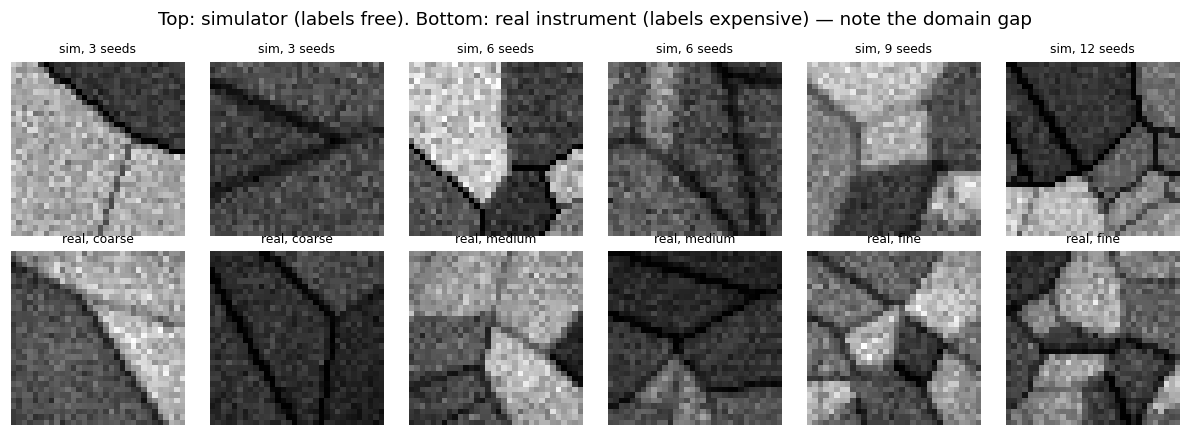

In [2]:
S = 32  # image size in pixels

def voronoi_image(n_seeds, rng, domain='sim'):
    # One Voronoi grain micrograph, shape (1, S, S).
    seeds = rng.uniform(0, S, (n_seeds, 2))
    yy, xx = np.mgrid[:S, :S]
    d2 = (yy[..., None] - seeds[:, 0]) ** 2 + (xx[..., None] - seeds[:, 1]) ** 2
    grain_id = d2.argmin(-1)
    img = rng.uniform(0.15, 0.90, n_seeds)[grain_id]          # channelling contrast per grain
    bnd = np.zeros((S, S))
    bnd[:-1] += grain_id[:-1] != grain_id[1:]
    bnd[:, :-1] += grain_id[:, :-1] != grain_id[:, 1:]
    img = img - 0.45 * np.clip(bnd, 0, 1)                       # dark grain boundaries
    if domain == 'sim':
        # simulator with domain randomisation: random blur and random dose, but no vignetting
        img = gaussian_filter(img, rng.uniform(0, 1.0))
        lam = rng.uniform(40, 150)
    else:
        # "real" instrument: fixed defocus blur, off-centre vignetting, gain/offset drift, low dose
        img = gaussian_filter(img, 0.6)
        cy, cx = rng.uniform(8, 24, 2)
        vignette = 1 - 0.3 * ((yy - cy) ** 2 + (xx - cx) ** 2) / (S ** 2 / 2)
        img = img * vignette * rng.uniform(0.7, 1.1) + rng.uniform(0, 0.1)
        lam = 80
    img = rng.poisson(lam * np.clip(img, 0.01, 1)) / lam        # Poisson shot noise
    return np.clip(img, 0, 1.5).astype(np.float32)[None]

def make_set(seed_counts, n_per_count, rng, domain):
    X, counts = [], []
    for sc in seed_counts:
        for _ in range(n_per_count):
            X.append(voronoi_image(sc, rng, domain)); counts.append(sc)
    return np.stack(X), np.array(counts)

def size_class(counts):
    # 0 = coarse (<6 grains), 1 = medium (6-9), 2 = fine (>=10)
    return np.digitize(counts, [6, 10])

rng = np.random.default_rng(SEED)
X_sim,  c_sim  = make_set([3, 6, 9, 12], 400, rng, 'sim')
y_sim = np.searchsorted([3, 6, 9, 12], c_sim)                    # 4 simulator classes
X_pool, _      = make_set(list(range(3, 15)), 125, rng, 'real')  # unlabelled: labels thrown away
REAL_COUNTS = [3, 4, 7, 8, 12, 13, 14]
X_lab,  c_lab  = make_set(REAL_COUNTS, 150, rng, 'real'); y_lab  = size_class(c_lab)
X_test, c_test = make_set(REAL_COUNTS, 90,  rng, 'real'); y_test = size_class(c_test)
CLASS_NAMES = ['coarse', 'medium', 'fine']

print(f"simulator : {X_sim.shape}  classes {np.bincount(y_sim)}")
print(f"unlabelled: {X_pool.shape}")
print(f"labelled  : {X_lab.shape}  classes {np.bincount(y_lab)}")
print(f"test      : {X_test.shape}  classes {np.bincount(y_test)}")

fig, axes = plt.subplots(2, 6, figsize=(11, 4))
for j in range(6):
    i = j * (len(X_sim) // 6)
    axes[0, j].imshow(X_sim[i, 0], cmap='gray', vmin=0, vmax=1.1)
    axes[0, j].set_title(f"sim, {c_sim[i]} seeds", fontsize=8)
    i = j * (len(X_lab) // 6)
    axes[1, j].imshow(X_lab[i, 0], cmap='gray', vmin=0, vmax=1.1)
    axes[1, j].set_title(f"real, {CLASS_NAMES[y_lab[i]]}", fontsize=8)
for ax in axes.ravel(): ax.axis('off')
fig.suptitle('Top: simulator (labels free). Bottom: real instrument (labels expensive) — note the domain gap')
plt.tight_layout(); plt.show()

# (try this yourself) — how would you convince a colleague that the two rows come from different domains?
#                        Compare histograms of X_sim and X_lab pixel values.

---

## Part 2 — Backbone, head and a minimal training loop

- **Backbone** $f_\theta$: three conv blocks + global average pooling → a **32-D embedding** $\mathbf{h} = f_\theta(\mathbf{x})$.
- **Head**: a single linear layer $\mathbf{h} \mapsto$ class logits.

The training loop supports **differential learning rates** (one parameter group for the backbone, one for the head) — the key tool for fine-tuning.

In [3]:
class Backbone(nn.Module):
    # (B, 1, 32, 32) -> (B, 32) embedding
    def __init__(self, w=16):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, w, 3, padding=1), nn.BatchNorm2d(w), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(w, 2 * w, 3, padding=1), nn.BatchNorm2d(2 * w), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(2 * w, 2 * w, 3, padding=1), nn.BatchNorm2d(2 * w), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1), nn.Flatten())
        self.dim = 2 * w
    def forward(self, x):
        return self.net(x)

class Classifier(nn.Module):
    def __init__(self, n_classes, backbone=None):
        super().__init__()
        self.backbone = backbone if backbone is not None else Backbone()
        self.head = nn.Linear(self.backbone.dim, n_classes)
    def forward(self, x):
        return self.head(self.backbone(x))

def train_supervised(model, X, y, epochs, lr_backbone=1e-3, lr_head=1e-3, batch_size=32):
    # Cross-entropy training with two parameter groups (differential learning rates).
    opt = torch.optim.Adam([{'params': model.backbone.parameters(), 'lr': lr_backbone},
                            {'params': model.head.parameters(),     'lr': lr_head}])
    X, y = torch.from_numpy(X), torch.from_numpy(y)
    for _ in range(epochs):
        model.train()
        perm = torch.randperm(len(X))
        for i in range(0, len(X), batch_size):
            idx = perm[i:i + batch_size]
            if len(idx) < 2:          # BatchNorm needs >= 2 samples
                continue
            loss = F.cross_entropy(model(X[idx]), y[idx])
            opt.zero_grad(); loss.backward(); opt.step()
    return model

@torch.no_grad()
def accuracy(model, X, y):
    model.eval()
    return float((model(torch.from_numpy(X)).argmax(1).numpy() == y).mean())

@torch.no_grad()
def embed(backbone, X):
    backbone.eval()
    return torch.cat([backbone(torch.from_numpy(X[i:i + 512])) for i in range(0, len(X), 512)]).numpy()

n_params = sum(p.numel() for p in Backbone().parameters())
print(f"Backbone parameters: {n_params:,}  (compare: ResNet-50 has ~25 M)")

Backbone parameters: 14,208  (compare: ResNet-50 has ~25 M)


---

## Part 3 — Backbone A: supervised pretraining on the simulator

Classic sim-to-real transfer: learn to count grains on unlimited synthetic labels, keep the backbone, throw away the 4-class head.

In [4]:
t0 = time.time()
torch.manual_seed(SEED)
perm = np.random.default_rng(SEED).permutation(len(X_sim))
tr, va = perm[:1300], perm[1300:]
model_sim = train_supervised(Classifier(4), X_sim[tr], y_sim[tr], epochs=8, batch_size=64)
acc_sim_val = accuracy(model_sim, X_sim[va], y_sim[va])
backbone_sim = model_sim.backbone
print(f"Simulator task (4-class grain count): validation accuracy = {acc_sim_val:.3f}   [{time.time()-t0:.0f} s]")
assert acc_sim_val > 0.6, "sim pretraining failed — the backbone would be useless"

Simulator task (4-class grain count): validation accuracy = 0.630   [10 s]


---

## Part 4 — Backbone B: self-supervised SimCLR on the unlabelled real pool

SimCLR [Chen et al. 2020] needs **no labels**. For a batch of $N$ images:

1. make two random augmented **views** of each image → $2N$ views;
2. encode with the backbone $f$ and a small **projector** $g$: $\mathbf{z} = g(f(\mathbf{x}))$;
3. the two views of the same image are the **positive pair**, the other $2N-2$ views are negatives;
4. minimise the **NT-Xent / InfoNCE** loss for each view $i$ with partner $j$:

$$\ell_{i} = -\log \frac{\exp(\mathrm{sim}(\mathbf{z}_i,\mathbf{z}_j)/\tau)}{\sum_{k\neq i}\exp(\mathrm{sim}(\mathbf{z}_i,\mathbf{z}_k)/\tau)}, \qquad \mathrm{sim}(\mathbf{u},\mathbf{v}) = \frac{\mathbf{u}^\top\mathbf{v}}{\|\mathbf{u}\|\,\|\mathbf{v}\|}.$$

It is a $(2N-1)$-way classification: "which of the other views is my twin?"

**The augmentations define what the embedding ignores.** Physics check for our task (the label is *grain size*):

| Augmentation | Physically OK here? |
|---|---|
| 90° rotations, flips | yes — equiaxed grains have no preferred direction |
| brightness/contrast jitter, extra noise | yes — gain drift and dose are nuisances |
| small translations | yes |
| **random zoom / rescale** | **NO** — scale *is* grain size. A zoom-invariant embedding cannot tell coarse from fine. |

NT-Xent, perfect twins: 0.090   uninformative: 2.708   log(2N-1) = 2.708


SimCLR: 30 epochs on 1500 unlabelled images   [59 s]


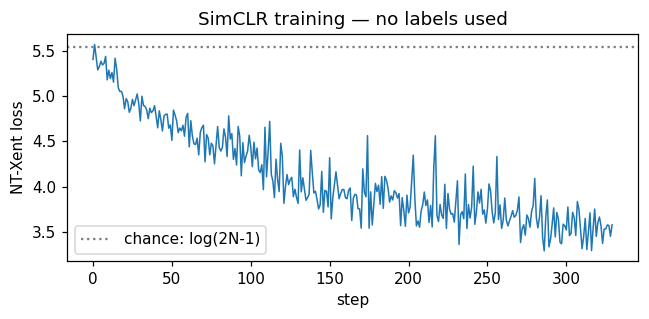

In [5]:
def augment(x):
    # Physics-respecting random views of a batch (B, 1, S, S). NO rescaling (scale = the label!).
    B = x.shape[0]
    x = torch.rot90(x, int(np.random.randint(4)), (2, 3))                   # 90° rotation
    flip = torch.rand(B) < 0.5
    x = torch.where(flip[:, None, None, None], x.flip(3), x)               # mirror
    x = x * (0.7 + 0.6 * torch.rand(B, 1, 1, 1)) + 0.2 * (torch.rand(B, 1, 1, 1) - 0.5)  # gain/offset
    x = x + 0.08 * torch.randn_like(x)                                      # extra noise
    xp = F.pad(x, (4, 4, 4, 4), mode='reflect')                             # small translation
    i, j = np.random.randint(0, 9, 2)
    return xp[:, :, i:i + S, j:j + S]

def nt_xent(z1, z2, tau=0.2):
    # NT-Xent (InfoNCE) loss for two batches of projections, each (N, d).
    z = F.normalize(torch.cat([z1, z2]), dim=1)       # (2N, d), unit length -> dot = cosine
    n = z1.shape[0]
    sim = z @ z.T / tau                                # (2N, 2N) similarity logits
    sim.fill_diagonal_(-1e9)                           # a view is not its own candidate
    target = torch.cat([torch.arange(n, 2 * n), torch.arange(0, n)])  # index of the twin view
    return F.cross_entropy(sim, target)

# Sanity check of the loss (N=8): identical twins, orthogonal images -> loss near 0;
# uninformative similarities (all equal, here via a huge tau) -> exactly log(2N-1)
z = torch.eye(8)
print(f"NT-Xent, perfect twins: {nt_xent(z, z).item():.3f}   uninformative: "
      f"{nt_xent(torch.randn(8, 8), torch.randn(8, 8), tau=1e6).item():.3f}   log(2N-1) = {np.log(15):.3f}")

t0 = time.time()
torch.manual_seed(SEED); np.random.seed(SEED)
backbone_ssl = Backbone()
projector = nn.Sequential(nn.Linear(32, 64), nn.ReLU(), nn.Linear(64, 32))
opt = torch.optim.Adam(list(backbone_ssl.parameters()) + list(projector.parameters()), lr=2e-3)
X_pool_t = torch.from_numpy(X_pool)
ssl_losses = []
EPOCHS_SSL, BATCH_SSL = 30, 128
for epoch in range(EPOCHS_SSL):
    backbone_ssl.train()
    perm = torch.randperm(len(X_pool_t))
    for i in range(0, len(X_pool_t) - BATCH_SSL + 1, BATCH_SSL):
        xb = X_pool_t[perm[i:i + BATCH_SSL]]
        loss = nt_xent(projector(backbone_ssl(augment(xb))), projector(backbone_ssl(augment(xb))))
        opt.zero_grad(); loss.backward(); opt.step()
        ssl_losses.append(loss.item())
print(f"SimCLR: {EPOCHS_SSL} epochs on {len(X_pool)} unlabelled images   [{time.time()-t0:.0f} s]")

plt.figure(figsize=(6, 3))
plt.plot(ssl_losses, lw=1)
plt.axhline(np.log(2 * BATCH_SSL - 1), color='gray', ls=':', label='chance: log(2N-1)')
plt.xlabel('step'); plt.ylabel('NT-Xent loss'); plt.title('SimCLR training — no labels used'); plt.legend()
plt.tight_layout(); plt.show()
assert ssl_losses[-1] < ssl_losses[0] - 0.5, "SimCLR loss did not decrease"

# A randomly initialised backbone as the "no pretraining" reference
torch.manual_seed(SEED)
backbone_rand = Backbone()

# (try this yourself) — add a random zoom to augment() (e.g. F.interpolate a random crop back to 32x32),
#                        retrain SimCLR and re-run Parts 5-6: what happens to linear-probe accuracy? Why?

---

## Part 5 — Looking at the embeddings: PCA maps and kNN retrieval

A frozen backbone turns every image into a vector $\mathbf{h}\in\mathbb{R}^{32}$. Two cheap diagnostics, before training any classifier:

- **PCA to 2-D**, coloured by the (held-back) class — do classes separate?
- **kNN retrieval**: for a query image, fetch the most similar images by **cosine similarity**. This is exactly what a "find similar micrographs in our archive" tool does.

(We only use the labels here to *evaluate* the embeddings — the backbones never saw real labels.)

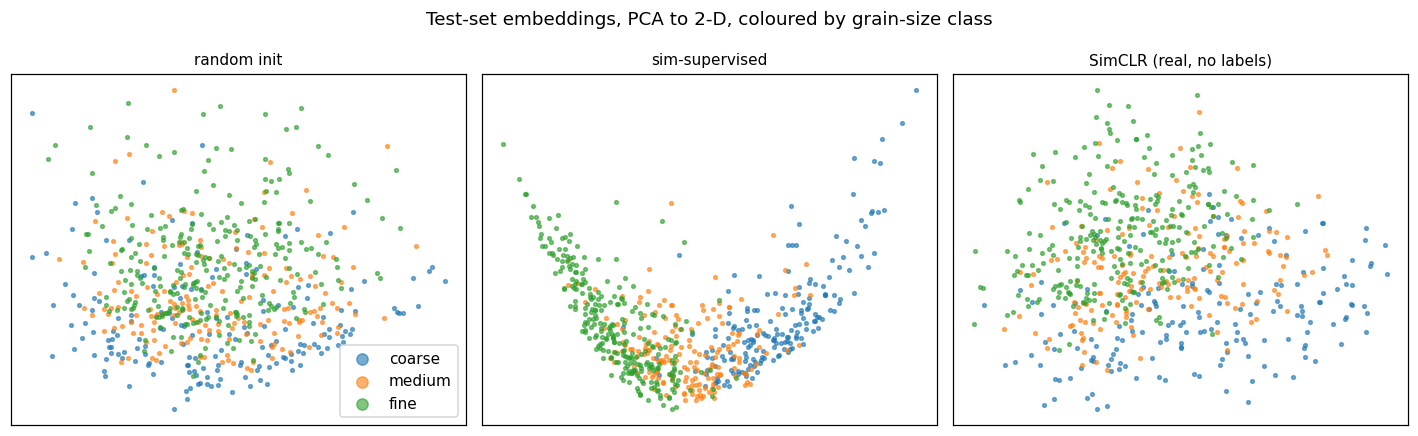

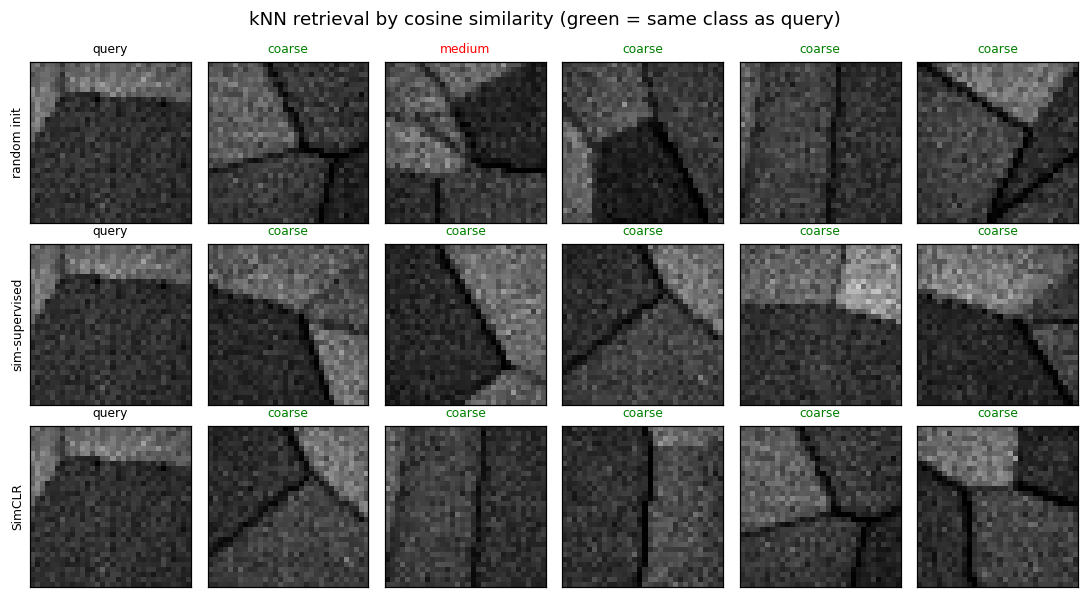

In [6]:
backbones = {'random init': backbone_rand, 'sim-supervised': backbone_sim, 'SimCLR (real, no labels)': backbone_ssl}
emb = {name: (embed(bb, X_lab), embed(bb, X_test)) for name, bb in backbones.items()}

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (name, (e_lab, e_test)) in zip(axes, emb.items()):
    p = PCA(2).fit_transform(StandardScaler().fit_transform(e_test))
    for c in range(3):
        ax.scatter(p[y_test == c, 0], p[y_test == c, 1], s=6, alpha=0.6, label=CLASS_NAMES[c])
    ax.set_title(name, fontsize=10); ax.set_xticks([]); ax.set_yticks([])
axes[0].legend(markerscale=3)
fig.suptitle('Test-set embeddings, PCA to 2-D, coloured by grain-size class')
plt.tight_layout(); plt.show()

def cosine_neighbours(E, query, k=5):
    En = E / np.linalg.norm(E, axis=1, keepdims=True)
    s = En @ En[query]
    s[query] = -np.inf
    return np.argsort(-s)[:k]

query = int(np.where(y_test == 0)[0][3])   # a coarse-grained query
fig, axes = plt.subplots(3, 6, figsize=(10, 5.5))
for r, (name, (_, e_test)) in enumerate(emb.items()):
    nbrs = cosine_neighbours(e_test, query)
    axes[r, 0].imshow(X_test[query, 0], cmap='gray', vmin=0, vmax=1.1)
    axes[r, 0].set_title('query', fontsize=8)
    axes[r, 0].set_ylabel(name.split(' (')[0], fontsize=8)
    for j, n in enumerate(nbrs):
        axes[r, j + 1].imshow(X_test[n, 0], cmap='gray', vmin=0, vmax=1.1)
        axes[r, j + 1].set_title(CLASS_NAMES[y_test[n]], fontsize=8,
                                 color='green' if y_test[n] == y_test[query] else 'red')
for ax in axes.ravel(): ax.set_xticks([]); ax.set_yticks([])
fig.suptitle('kNN retrieval by cosine similarity (green = same class as query)')
plt.tight_layout(); plt.show()

### Exercise 1 — precision@k for embedding retrieval

A single query is an anecdote. Quantify retrieval with **precision@k**: for *every* image, find its $k$ nearest neighbours (cosine similarity, excluding itself) and compute the fraction that share its class; average over all images.
Chance level for 3 balanced-ish classes is ≈ 1/3.

**TODO:** complete `precision_at_k(E, y, k)`. The cell ships with a working version — cover it up and write your own first.

In [7]:
def precision_at_k(E, y, k=5):
    # TODO 1: L2-normalise the rows of E so that a dot product is a cosine similarity
    En = E / np.linalg.norm(E, axis=1, keepdims=True)
    # TODO 2: full (n, n) similarity matrix; exclude self-matches by setting the diagonal to -inf
    S_ = En @ En.T
    np.fill_diagonal(S_, -np.inf)
    # TODO 3: indices of the k most similar images for every row
    nbrs = np.argsort(-S_, axis=1)[:, :k]
    # TODO 4: fraction of neighbours with the same label, averaged over all queries
    return float((y[nbrs] == y[:, None]).mean())

p_at_5 = {name: precision_at_k(e_test, y_test, k=5) for name, (_, e_test) in emb.items()}
for name, p in p_at_5.items():
    print(f"precision@5  {name:26s}: {p:.3f}")

assert p_at_5['SimCLR (real, no labels)'] > p_at_5['random init'], "SimCLR should beat random features"
assert p_at_5['sim-supervised'] > p_at_5['random init'], "sim pretraining should beat random features"
print("Exercise 1 assertions passed.")

precision@5  random init               : 0.514
precision@5  sim-supervised            : 0.715
precision@5  SimCLR (real, no labels)  : 0.671
Exercise 1 assertions passed.


### Solution

*(Non-executable — read only after you have tried the exercise.)*

```python
def precision_at_k(E, y, k=5):
    En = E / np.linalg.norm(E, axis=1, keepdims=True)   # rows on the unit sphere
    S_ = En @ En.T                                       # cosine similarities
    np.fill_diagonal(S_, -np.inf)                        # never retrieve yourself
    nbrs = np.argsort(-S_, axis=1)[:, :k]                # top-k per row
    return float((y[nbrs] == y[:, None]).mean())
# Values (SEED=42): random ≈ 0.51, SimCLR ≈ 0.67, sim-supervised ≈ 0.72 (chance ≈ 0.33).
# Why is the random backbone above chance? Conv + pooling on edges already measures "boundary
# density" crudely — architecture is itself an inductive bias (Week 7).
```

---

## Part 6 — Protocols vs number of labels: scratch · linear probe · fine-tune

The standard evaluation protocol for a pretrained representation:

| Protocol | Trained | Frozen | When it shines |
|---|---|---|---|
| **From scratch** | everything, random init | — | lots of labels |
| **Linear probe (LP)** | a logistic regression on $\mathbf{h}$ | the whole backbone | very few labels; also *measures* embedding quality |
| **LP → fine-tune (LP-FT)** | backbone (small lr) + head, head initialised from the LP | — | moderate labels, domain gap |

Why initialise the head from the probe? A random head sends large, random gradients into the pretrained backbone in the first steps and *distorts* the features (catastrophic forgetting). Starting from the probe head plus a small learning rate avoids that.

We sweep the number of real labels $N \in \{9, 30, 90, 300\}$ (balanced), 2 random draws each, and always evaluate on the same untouched test set.

N=   9: LP: random init=0.424  LP: sim-supervised=0.685  LP: SimCLR=0.571  from scratch=0.559  LP→FT: SimCLR=0.575   [14 s]


N=  30: LP: random init=0.531  LP: sim-supervised=0.664  LP: SimCLR=0.662  from scratch=0.613  LP→FT: SimCLR=0.650   [36 s]


N=  90: LP: random init=0.576  LP: sim-supervised=0.769  LP: SimCLR=0.763  from scratch=0.667  LP→FT: SimCLR=0.729   [59 s]


N= 300: LP: random init=0.658  LP: sim-supervised=0.798  LP: SimCLR=0.821  from scratch=0.624  LP→FT: SimCLR=0.852   [81 s]


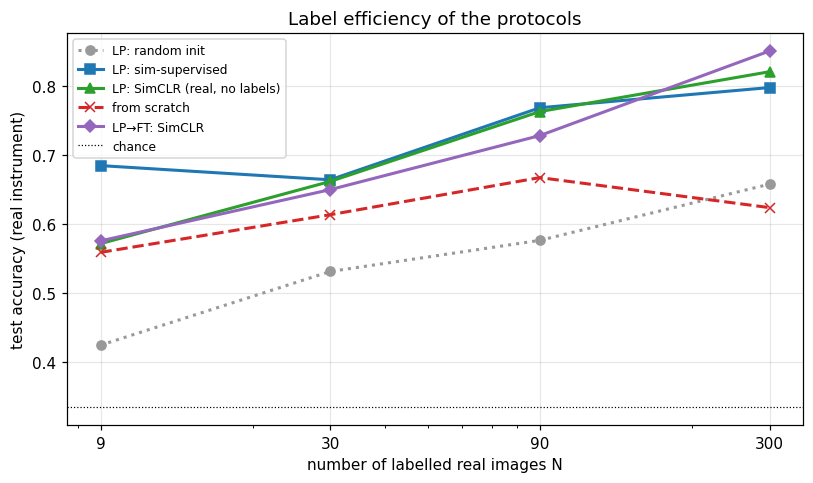

In [8]:
def linear_probe(e_train, y_train, e_test, y_test_):
    clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, C=1.0))
    clf.fit(e_train, y_train)
    return clf.score(e_test, y_test_), clf

def head_from_probe(model, clf):
    # Copy the (standardised) logistic regression into the linear head: fold the scaler into W, b.
    sc, lr = clf[0], clf[1]
    W = lr.coef_ / sc.scale_
    b = lr.intercept_ - (W * sc.mean_).sum(1)
    with torch.no_grad():
        model.head.weight.copy_(torch.tensor(W, dtype=torch.float32))
        model.head.bias.copy_(torch.tensor(b, dtype=torch.float32))
    return model

N_VALUES = [9, 30, 90, 300]
RUNS = 2
STEPS = 250            # gradient steps for the trainable protocols (same budget for every N)
results = {}           # (protocol, N) -> list of test accuracies
t0 = time.time()
for N in N_VALUES:
    for run in range(RUNS):
        rr = np.random.default_rng(1000 + run)
        idx = np.concatenate([rr.choice(np.where(y_lab == c)[0], N // 3, replace=False) for c in range(3)])
        Xtr, ytr = X_lab[idx], y_lab[idx]
        epochs = int(np.clip(np.ceil(STEPS * 32 / N), 10, 300))

        # 1) linear probes on three frozen backbones
        for name, (e_lab, e_test) in emb.items():
            acc_lp, clf = linear_probe(e_lab[idx], ytr, e_test, y_test)
            results.setdefault(('LP: ' + name, N), []).append(acc_lp)
            if name.startswith('SimCLR'):
                clf_ssl = clf

        # 2) from scratch
        torch.manual_seed(run)
        m = train_supervised(Classifier(3), Xtr, ytr, epochs=epochs)
        results.setdefault(('from scratch', N), []).append(accuracy(m, X_test, y_test))

        # 3) LP -> fine-tune the SimCLR backbone (small, equal learning rates)
        torch.manual_seed(run)
        m = head_from_probe(Classifier(3, copy.deepcopy(backbone_ssl)), clf_ssl)
        m = train_supervised(m, Xtr, ytr, epochs=epochs, lr_backbone=1e-4, lr_head=1e-4)
        results.setdefault(('LP→FT: SimCLR', N), []).append(accuracy(m, X_test, y_test))
    print(f"N={N:4d}: " + "  ".join(f"{k[0].split(' (')[0]}={np.mean(v):.3f}"
                                    for k, v in results.items() if k[1] == N) + f"   [{time.time()-t0:.0f} s]")

mean_acc = {k: float(np.mean(v)) for k, v in results.items()}
protocols = list(dict.fromkeys(k[0] for k in results))
styles = {'LP: random init': ('0.6', ':', 'o'), 'LP: sim-supervised': ('tab:blue', '-', 's'),
          'LP: SimCLR (real, no labels)': ('tab:green', '-', '^'), 'from scratch': ('tab:red', '--', 'x'),
          'LP→FT: SimCLR': ('tab:purple', '-', 'D')}
plt.figure(figsize=(7.5, 4.5))
for p in protocols:
    col, ls, mk = styles[p]
    plt.plot(N_VALUES, [mean_acc[(p, N)] for N in N_VALUES], color=col, ls=ls, marker=mk, lw=2, label=p)
plt.axhline(1 / 3, color='k', lw=0.8, ls=':', label='chance')
plt.xscale('log'); plt.xticks(N_VALUES, [str(n) for n in N_VALUES])
plt.xlabel('number of labelled real images N'); plt.ylabel('test accuracy (real instrument)')
plt.title('Label efficiency of the protocols'); plt.legend(fontsize=8); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [9]:
# --- Self-check: the lecture claims, measured -------------------------------------
lp_ssl, lp_sim, lp_rand = 'LP: SimCLR (real, no labels)', 'LP: sim-supervised', 'LP: random init'
# 1. With very few labels, any sensible pretrained probe beats training from scratch.
assert mean_acc[(lp_sim, 9)] > mean_acc[('from scratch', 9)]
# 2. Pretraining matters: SimCLR / sim features beat random features at every N.
assert all(mean_acc[(lp_ssl, N)] > mean_acc[(lp_rand, N)] for N in N_VALUES)
# 3. SimCLR probe improves with more labels (the embedding contains more than 9 labels can reveal).
assert mean_acc[(lp_ssl, 300)] > mean_acc[(lp_ssl, 9)]
# 4. With enough labels, fine-tuning (LP-FT) beats the frozen SimCLR probe it started from.
assert mean_acc[('LP→FT: SimCLR', 300)] > mean_acc[(lp_ssl, 300)] - 0.01
print("All protocol assertions passed.")
print(f"N=9  : scratch {mean_acc[('from scratch', 9)]:.2f} | LP sim {mean_acc[(lp_sim, 9)]:.2f} | "
      f"LP SimCLR {mean_acc[(lp_ssl, 9)]:.2f} | LP-FT {mean_acc[('LP→FT: SimCLR', 9)]:.2f}")
print(f"N=300: scratch {mean_acc[('from scratch', 300)]:.2f} | LP sim {mean_acc[(lp_sim, 300)]:.2f} | "
      f"LP SimCLR {mean_acc[(lp_ssl, 300)]:.2f} | LP-FT {mean_acc[('LP→FT: SimCLR', 300)]:.2f}")
print(f"Total notebook runtime so far: {time.time() - T_START:.0f} s")

# (try this yourself) — replace head_from_probe(...) by a random head and lr_backbone=3e-4, lr_head=1e-3
#                        ("naive fine-tuning"). Is it better or worse than LP-FT at N=300? At N=9?
# (try this yourself) — increase STEPS for "from scratch" to 1000. How much of its deficit is just
#                        under-training, and how much is lack of data?

All protocol assertions passed.
N=9  : scratch 0.56 | LP sim 0.68 | LP SimCLR 0.57 | LP-FT 0.58
N=300: scratch 0.62 | LP sim 0.80 | LP SimCLR 0.82 | LP-FT 0.85
Total notebook runtime so far: 156 s


### Exercise 2 — read the curves (discussion, no code)

Answer in two sentences each, using the numbers you measured:

1. At $N=9$, which protocol wins and why is fine-tuning risky there?
2. The **sim-supervised** backbone is strong at small $N$ even though the simulator looks different from the real instrument. What property of the simulator task makes its features transferable? What would happen if the simulator had been trained on a task unrelated to grain size (e.g. mean brightness)?
3. The **SimCLR** backbone never saw a label, yet catches up with (or overtakes) sim-supervised features at large $N$. What does SimCLR exploit that the simulator cannot provide?

### Solution

*(Non-executable — read only after you have tried the exercise.)*

```text
Typical numbers (SEED=42, 2 draws per N):
  N=9  : scratch 0.56, LP sim 0.68, LP SimCLR 0.57, LP-FT 0.58
  N=300: scratch 0.62, LP sim 0.80, LP SimCLR 0.82, LP-FT 0.85
1. The linear probe on the sim-supervised backbone. With 9 labels, fine-tuning ~14k backbone
   parameters buys nothing over the probe it started from (0.58 vs 0.57) and can easily
   overfit/distort the features; a 3x33-parameter probe cannot.
2. The simulator task (grain counting) needs exactly the feature the real task needs (boundary
   density = grain size). Domain randomisation (blur, dose) made that feature robust to the gap.
   A brightness task would teach nothing about boundaries -> no transfer (or negative transfer).
3. The real instrument's own image statistics (vignetting, blur, noise) — the unlabelled pool
   is in-domain. With augmentations that respect the physics (no zoom!), the embedding keeps
   grain-size information while ignoring gain, orientation and noise.
Scratch stays low here mainly because 250 steps on 32x32 images are too few for random init —
the real-world version of "not enough labels AND not enough compute".
```

---

## Part 7 (optional) — frozen ImageNet features

In a real project you would first try a large pretrained backbone (ResNet, DINOv2) as a frozen feature extractor + linear probe.
This cell downloads ~45 MB of ResNet-18 weights, so it is **off by default**. Set `USE_IMAGENET = True` to try it (grey → 3 channels by replication, resize to 64×64).

In [10]:
USE_IMAGENET = False   # set True to download ResNet-18 ImageNet weights (~45 MB)

if USE_IMAGENET:
    try:
        import torchvision
        rn = torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights.DEFAULT)
        rn.fc = nn.Identity(); rn.eval()
        mean = torch.tensor([0.485, 0.456, 0.406])[None, :, None, None]
        std = torch.tensor([0.229, 0.224, 0.225])[None, :, None, None]
        @torch.no_grad()
        def embed_imagenet(X):
            out = []
            for i in range(0, len(X), 256):
                x = torch.from_numpy(X[i:i + 256]).clamp(0, 1).repeat(1, 3, 1, 1)   # replicate grey -> RGB
                x = F.interpolate(x, size=64, mode='bilinear', align_corners=False)
                out.append(rn((x - mean) / std))
            return torch.cat(out).numpy()
        e_lab_in, e_test_in = embed_imagenet(X_lab), embed_imagenet(X_test)
        print(f"ImageNet ResNet-18 precision@5: {precision_at_k(e_test_in, y_test):.3f}")
        for N in N_VALUES:
            idx = np.concatenate([np.random.default_rng(1000).choice(np.where(y_lab == c)[0], N // 3, replace=False)
                                  for c in range(3)])
            print(f"  LP ImageNet, N={N:4d}: {linear_probe(e_lab_in[idx], y_lab[idx], e_test_in, y_test)[0]:.3f}")
    except Exception as err:
        print("ImageNet cell skipped:", err)
else:
    print("Skipped (USE_IMAGENET = False).")

Skipped (USE_IMAGENET = False).


---

## Summary

| Concept | What you measured |
|---|---|
| Embeddings + kNN retrieval | precision@5: random ≈ 0.51 · SimCLR ≈ 0.67 · sim-supervised ≈ 0.72 (chance 0.33) |
| Linear probe = cheapest, safest protocol | sim-supervised probe best at N = 9 (0.68 vs 0.56 from scratch) |
| LP → fine-tune | no gain at N = 9; best protocol at N = 300 (0.85 vs 0.82 probe, 0.62 scratch) |
| Self-supervision (SimCLR) | no labels at all, yet overtakes sim-supervised features at N = 300 (0.82 vs 0.80) |
| Physics decides augmentation | zoom would destroy the grain-size information (try it!) |

**Take-home recipe for your miniproject:** frozen pretrained embedding → kNN sanity check → linear probe baseline → fine-tune only if it beats the probe on a *specimen-grouped* validation split.

**Week 9 preview:** unsupervised learning goes one step further — autoencoders, VAEs and clustering in latent space, and how 2-D maps of those latent spaces can mislead.

---

*Data Science for Electron Microscopy — Week 8 self-study notebook*  
*Prof. Dr. Philipp Pelz — FAU Erlangen-Nürnberg*